In [1]:
!pip install -U langgraph

In [2]:
from langgraph.graph import StateGraph,START,END

In [3]:
from typing import TypedDict

In [21]:
class TemperatureState(TypedDict):
  temp_celsius:float
  temp_fahrenheit:float
  weather:str

In [22]:
def convert_temp(state:TemperatureState)->TemperatureState:
  celsius=state['temp_celsius']
  fahrenheit=(celsius * 9/5)+32
  state['temp_fahrenheit']=round(fahrenheit,2)
  return state



In [29]:
def label_weather(state:TemperatureState)->TemperatureState:
  fah=state['temp_fahrenheit']
  if fah<77:
    state['weather']='COLD'
  if fah>77 and fah<90:
    state['weather']='Mild hot'
  if fah>90 and fah<100:
    state['weather']='hot'
  if fah>100:
    state['weather']='Very hot'
  return state


In [30]:
graph=StateGraph(TemperatureState)
graph.add_node('convert_temp',convert_temp)
graph.add_node('label_weather',label_weather)

graph.add_edge(START,'convert_temp')
graph.add_edge('convert_temp','label_weather')
graph.add_edge('label_weather',END)


workflow=graph.compile()

In [31]:
initial_state={'temp_celsius':28.5}
final_state=workflow.invoke(initial_state)
print(final_state)

{'temp_celsius': 28.5, 'temp_fahrenheit': 83.3, 'weather': 'Mild hot'}


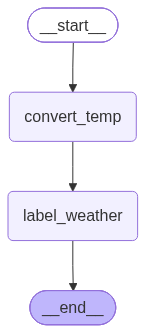

In [32]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [33]:
!pip install langchain-groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.0 MB/s eta 0:00:00


In [34]:
##llm workflow  start------>llmqa----->end
from langchain_groq import ChatGroq
from typing import TypedDict


In [37]:
from google.colab import userdata
groq_api_key=userdata.get('GROQ_API_KEY')

In [47]:
llm = ChatGroq(
    model_name="openai/gpt-oss-120b",
    temperature=0.7,
    api_key=groq_api_key
)

In [48]:
class LLMState(TypedDict):
  question:str
  answer:str


In [49]:
def llm_qa(state:LLMState)->LLMState:
  question=state['question']
  prompt=f"Answer the following question: {question}"
  answer=llm.invoke(prompt).content
  state['answer']=answer
  return state



In [50]:
graph=StateGraph(LLMState)
graph.add_node('llm_qa',llm_qa)

graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)

workflow=graph.compile()

In [53]:
question={'question':"what is  Artificial Intelligence"}
final_state=workflow.invoke(question)
print(final_state['answer'])

**Artificial Intelligence (AI)** is a branch of computer science that focuses on creating machines and software capable of performing tasks that normally require human intelligence. These tasks include, but are not limited to:

| Aspect of Intelligence | Typical Human Ability | AI Equivalent |
|------------------------|-----------------------|---------------|
| **Perception** | Seeing, hearing, sensing the environment | Computer vision, speech recognition, sensor data processing |
| **Reasoning & Problem‑Solving** | Logical deduction, planning, decision‑making | Knowledge representation, inference engines, reinforcement learning |
| **Learning** | Acquiring new knowledge from experience | Machine learning (supervised, unsupervised, semi‑supervised, reinforcement) |
| **Language Understanding** | Reading, writing, conversing | Natural language processing (NLP), chatbots, translation |
| **Adaptation & Creativity** | Adjusting to new situations, generating novel ideas | Generative models

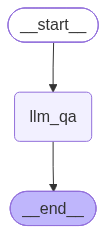

In [54]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [55]:
##prompt chaining workflow --- sequential workflow
### start----->create_outline---->create_post------>end
class LLMStates(TypedDict):
  title:str
  outline:str
  content:str

In [56]:
model = ChatGroq(
    model_name="openai/gpt-oss-120b",
    temperature=0.7,
    api_key=groq_api_key
)

In [65]:
def create_outline(state:LLMStates)->LLMStates:
  title=state['title']
  prompt1=f"Generate a clear and concise outline for the following title: {title}"
  outline=model.invoke(prompt1).content
  state['outline']=outline
  return state

In [66]:
def create_post(state:LLMStates)->LLMStates:
  outline=state['outline']
  prompt2=f"Write a clear, engaging post based on the following outline. Keep it informative, well-structured, and easy to understand:{outline}"
  content=model.invoke(prompt2).content
  state['content']=content
  return state


In [67]:
graph=StateGraph(LLMStates)
graph.add_node('create_outline',create_outline)
graph.add_node('create_post',create_post)

graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_post')
graph.add_edge('create_post',END)

workflow=graph.compile()


In [68]:
input_state={'title':"Write the post on the Generative AI"}
final_state=workflow.invoke(input_state)

In [72]:
print(final_state['outline'])

**Outline: “Understanding Generative AI – What It Is, How It Works, and Why It Matters”**

---

### 1. Introduction  
- Hook: A striking example (e.g., AI‑generated artwork, text, or music).  
- Brief definition of generative AI.  
- Purpose of the post – demystify the technology and explore its impact.

### 2. Core Concepts  
#### 2.1. What Makes AI “Generative”?  
- Difference between discriminative vs. generative models.  
- Goal: produce new, realistic data rather than just classify.

#### 2.2. Key Model Families  
- **Generative Adversarial Networks (GANs)** – generator vs. discriminator.  
- **Variational Autoencoders (VAEs)** – latent space sampling.  
- **Transformer‑based models** (e.g., GPT, BERT‑2‑BERT, DALL‑E) – autoregressive decoding.

#### 2.3. Training Basics  
- Large‑scale datasets & self‑supervision.  
- Loss functions (adversarial loss, reconstruction loss, likelihood).  
- Importance of compute resources.

### 3. Real‑World Applications  
- **Content creation** – t

In [71]:
print(final_state['content'])

## Understanding Generative AI – What It Is, How It Works, and Why It Matters  

---

### 1. Introduction  

Imagine opening a music‑streaming app and hearing a brand‑new symphony that sounds as if Beethoven had written it today. Or scrolling through a social feed and seeing a hyper‑realistic portrait of a person who doesn’t exist. Those are **generative AI** in action—machines that create text, images, audio, and even code that can be indistinguishable from human‑made content.  

**Generative AI** refers to a class of machine‑learning models that *produce* new data rather than just *recognize* or *classify* existing data. This post will demystify the technology, walk you through the core ideas, showcase real‑world uses, and highlight the opportunities and responsibilities that come with it.

---

### 2. Core Concepts  

#### 2.1. What Makes AI “Generative”?  

| **Discriminative Models** | **Generative Models** |
|---------------------------|-----------------------|
| Learn to *label*